# 13 Recommender Optimization

This notebook improves the existing content-based recommender by testing different feature groups and weighting strategies.

The goal is to find whether Spotify audio features, extracted low-level audio features, lyrics features, or weighted combinations of them produce better recommendations than the previous Model A and Model B.

The optimized model will later be used as the basis for the interactive recommendation demo.

In [15]:
from pathlib import Path
import sys
import warnings
import ast
import gc
import time

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

processed_dir = PROJECT_ROOT / "data" / "processed"
models_dir = processed_dir / "models"

print("Project root:", PROJECT_ROOT)
print("Processed data:", processed_dir)

Project root: c:\Users\hp\OneDrive - WU Wien\Desktop\Denis_Masters\Semester 2\Solution Engineering - Python\Spotify_Project\spotify_project
Processed data: c:\Users\hp\OneDrive - WU Wien\Desktop\Denis_Masters\Semester 2\Solution Engineering - Python\Spotify_Project\spotify_project\data\processed


In [16]:
tracks = pd.read_parquet(processed_dir / "tracks_with_predicted_genres.parquet")
audio_features = pd.read_parquet(processed_dir / "audio_features_clean.parquet")
lyrics_features = pd.read_parquet(processed_dir / "lyrics_features_valid_clean.parquet")
albums = pd.read_parquet(processed_dir / "albums_clean.parquet")
artists = pd.read_parquet(processed_dir / "artists_clean.parquet")

print(f"Tracks with predicted genres: {len(tracks):,}")
print(f"Audio features: {len(audio_features):,}")
print(f"Lyrics features: {len(lyrics_features):,}")
print(f"Albums: {len(albums):,}")
print(f"Artists: {len(artists):,}")

Tracks with predicted genres: 95,977
Audio features: 95,948
Lyrics features: 74,128
Albums: 75,511
Artists: 56,129


In [17]:
print("Tracks columns:")
print(tracks.columns.tolist())

print("\nAudio feature columns:")
print(audio_features.columns[:30].tolist())

print("\nLyrics feature columns:")
print(lyrics_features.columns.tolist())

Tracks columns:
['acousticness', 'album_id', 'analysis_url', 'artists_id', 'available_markets', 'country', 'danceability', 'disc_number', 'duration_ms', 'energy', 'href', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'lyrics', 'mode', 'name', 'playlist', 'popularity', 'preview_url', 'speechiness', 'tempo', 'time_signature', 'track_href', 'track_name_prev', 'track_number', 'uri', 'valence', 'genre_list', 'genre_canonical', 'predicted_genre_list']

Audio feature columns:
['Chroma_1', 'Chroma_10', 'Chroma_11', 'Chroma_12', 'Chroma_2', 'Chroma_3', 'Chroma_4', 'Chroma_5', 'Chroma_6', 'Chroma_7', 'Chroma_8', 'Chroma_9', 'MEL_1', 'MEL_10', 'MEL_100', 'MEL_101', 'MEL_102', 'MEL_103', 'MEL_104', 'MEL_105', 'MEL_106', 'MEL_107', 'MEL_108', 'MEL_109', 'MEL_11', 'MEL_110', 'MEL_111', 'MEL_112', 'MEL_113', 'MEL_114']

Lyrics feature columns:
['mean_syllables_word', 'mean_words_sentence', 'n_sentences', 'n_words', 'sentence_similarity', 'track_id', 'vocabulary_wealth']


## Feature Group Identification

Before optimizing the recommender, we first inspect the available feature groups.

The recommender currently combines three different types of information:

- Spotify audio features
- Extracted low-level audio features
- Lyrics features

Understanding how many features belong to each group is important before testing weighting strategies, since very large feature groups may dominate the similarity calculation.

In [18]:
spotify_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo",
    "loudness",
    "popularity"
]

lyrics_columns = lyrics_features.columns.drop("track_id").tolist()

audio_columns = audio_features.columns.tolist()

feature_groups = {
    "Spotify": spotify_features,
    "Lyrics": lyrics_columns,
    "Extracted Audio": audio_columns
}

summary = pd.DataFrame({
    "Feature Group": feature_groups.keys(),
    "Number of Features": [len(v) for v in feature_groups.values()]
})

summary

,Feature Group,Number of Features
0,Spotify,10
1,Lyrics,6
2,Extracted Audio,208


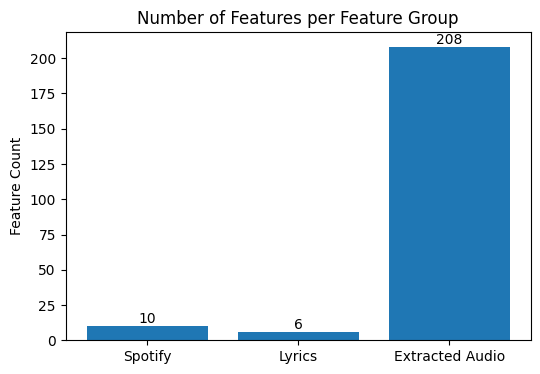

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    summary["Feature Group"],
    summary["Number of Features"]
)

plt.title("Number of Features per Feature Group")
plt.ylabel("Feature Count")

for i, value in enumerate(summary["Number of Features"]):
    plt.text(i, value + 2, str(value), ha="center")

plt.show()

## Building the Optimization Dataset

To compare different feature groups fairly, we first build one shared dataset that contains:

- track metadata
- predicted genres
- Spotify audio features
- extracted audio features
- lyrics features

Only tracks that have all required feature groups are kept. This makes the model comparisons fair, because every variant is evaluated on the same set of tracks.

In [20]:
optimization_df = (
    tracks
    .merge(
        audio_features,
        left_on="id",
        right_on="track_id",
        how="inner"
    )
    .merge(
        lyrics_features,
        left_on="id",
        right_on="track_id",
        how="inner",
        suffixes=("", "_lyrics")
    )
)

print(f"Optimization dataset rows: {len(optimization_df):,}")
print(f"Optimization dataset columns: {len(optimization_df.columns):,}")

optimization_df.head()

Optimization dataset rows: 74,103
Optimization dataset columns: 248


,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,energy,...,spectral_rollOff_max,spectral_rollOff_min,track_id,mean_syllables_word,mean_words_sentence,n_sentences,n_words,sentence_similarity,track_id_lyrics,vocabulary_wealth
0,0.971,7CCwkPweMxKq8yWkVerH6T,https://api.spotify.com/v1/audio-analysis/4PrA...,['3kzwYV3OCB010YfXMF0Avt'],"['AE', 'AR', 'BH', 'BO', 'BR', 'CL', 'CO', 'CR...",BE,0.367,1.0,183653.0,0.349,...,3117.222817,260.398425,4PrAZpH9Ic7S47E78BN6E4,1.49,3.17,24,133,0.021739,4PrAZpH9Ic7S47E78BN6E4,0.70
1,0.101,7noNViHJAYZ3UxlhDNKAt9,https://api.spotify.com/v1/audio-analysis/01zM...,"['3FLUBwpAnaIlIKeaBfsxFe', '5r5Va4lVQ1zjEfbJSr...","['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.748,1.0,237667.0,0.666,...,6184.462603,155.632392,01zME4q62SDPtD0hOSmTrG,1.18,4.30,46,331,0.068599,01zME4q62SDPtD0hOSmTrG,0.53
2,0.109,6TQBSDaY7mVEjwK3QxQUfA,https://api.spotify.com/v1/audio-analysis/2D0t...,['12j6dJrPXanCBwY599pZxf'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.801,1.0,167043.0,0.610,...,5596.299493,154.715731,2D0the6JBRyOpMeBkPFkGY,1.26,3.38,40,220,0.055128,2D0the6JBRyOpMeBkPFkGY,0.55
3,0.471,3Pw2DsAYlat4wHjVrQHYhT,https://api.spotify.com/v1/audio-analysis/0tew...,['3EQ310YOzcS1pJqiaoDs32'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.515,1.0,261123.0,0.351,...,3665.102838,91.857778,0tewjlNbotxqF2obibsg36,1.42,2.89,38,239,0.035562,0tewjlNbotxqF2obibsg36,0.63
4,0.191,6cflCkqI3e9MHkm7rZlkXA,https://api.spotify.com/v1/audio-analysis/2Dh5...,['06Iig2bqY8mv98B1c9Iyo8'],"['AD', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE...",BE,0.608,1.0,243667.0,0.664,...,5003.953075,128.557556,2Dh5wED4UVeiBqneUdc5Gy,1.22,3.21,58,333,0.033273,2Dh5wED4UVeiBqneUdc5Gy,0.55


In [21]:
duplicate_track_id_cols = [
    col for col in optimization_df.columns 
    if "track_id" in col and col != "track_id"
]

duplicate_track_id_cols

['track_id_lyrics']

In [22]:
optimization_df = optimization_df.drop(
    columns=duplicate_track_id_cols,
    errors="ignore"
)

print(optimization_df.shape)

(74103, 247)


In [23]:
def to_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, np.ndarray):
        return val.tolist()
    if pd.isna(val):
        return []
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return [val]
    return []

optimization_df["eval_genres"] = optimization_df["predicted_genre_list"].apply(to_list)

optimization_df[["name", "predicted_genre_list", "eval_genres"]].head()

,name,predicted_genre_list,eval_genres
0,Already Gone,"[rock, pop, other]","[rock, pop, other]"
1,Creature Kind,"[rnb_soul, pop, other, electronic]","[rnb_soul, pop, other, electronic]"
2,Greatest Comedian,[folk_acoustic],[folk_acoustic]
3,I Wish I Was A Shark,[rock],[rock]
4,Cola Falls,"[rock, other]","[rock, other]"


In [24]:
print("Rows:", len(optimization_df))
print("Tracks with empty genre list:", (optimization_df["eval_genres"].str.len() == 0).sum())
print("Unique predicted genres:")

all_genres = optimization_df["eval_genres"].explode()
all_genres.value_counts()

Rows: 74103
Tracks with empty genre list: 2698
Unique predicted genres:


eval_genres
pop              44348
other            30214
rock             16435
hip_hop          14537
latin             6786
electronic        6704
rnb_soul          4615
folk_acoustic     3770
country           3062
jazz              2528
metal             2489
classical         1366
lofi               446
experimental       239
Name: count, dtype: int64

## Filtering Evaluation Rows

Some tracks do not have any predicted parent genre assigned. Since the optimization uses genre overlap as one evaluation signal, these tracks cannot be evaluated fairly.

We remove tracks with empty genre lists before building the feature-group recommender variants.

In [25]:
optimization_df = optimization_df[
    optimization_df["eval_genres"].str.len() > 0
].reset_index(drop=True)

print(f"Rows after removing empty genre lists: {len(optimization_df):,}")

optimization_df["eval_genres"].explode().value_counts()

Rows after removing empty genre lists: 71,405


eval_genres
pop              44348
other            30214
rock             16435
hip_hop          14537
latin             6786
electronic        6704
rnb_soul          4615
folk_acoustic     3770
country           3062
jazz              2528
metal             2489
classical         1366
lofi               446
experimental       239
Name: count, dtype: int64

## Final Feature Groups

The optimization compares three main feature groups:

1. Spotify audio features
2. Lyrics features
3. Extracted low-level audio features

The extracted audio group is much larger than the other two groups, so it is evaluated separately instead of assuming that more dimensions automatically improve the recommender.

In [26]:
spotify_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo",
    "loudness",
    "popularity"
]

lyrics_features_final = [
    "mean_syllables_word",
    "mean_words_sentence",
    "n_sentences",
    "n_words",
    "sentence_similarity",
    "vocabulary_wealth"
]

metadata_cols = set(tracks.columns.tolist()) | {
    "track_id",
    "track_id_lyrics",
    "eval_genres"
}

excluded_cols = metadata_cols | set(spotify_features) | set(lyrics_features_final)

extracted_audio_features = [
    col for col in optimization_df.columns
    if col not in excluded_cols
    and pd.api.types.is_numeric_dtype(optimization_df[col])
]

feature_group_summary = pd.DataFrame({
    "Feature Group": ["Spotify", "Lyrics", "Extracted Audio"],
    "Number of Features": [
        len(spotify_features),
        len(lyrics_features_final),
        len(extracted_audio_features)
    ]
})

feature_group_summary

,Feature Group,Number of Features
0,Spotify,10
1,Lyrics,6
2,Extracted Audio,207


In [27]:
for group_name, columns in {
    "Spotify": spotify_features,
    "Lyrics": lyrics_features_final,
    "Extracted Audio": extracted_audio_features
}.items():
    missing = optimization_df[columns].isna().sum().sum()
    print(f"{group_name}: {missing:,} missing values")

Spotify: 0 missing values
Lyrics: 0 missing values
Extracted Audio: 0 missing values


## Evaluation Helpers

To compare different recommender variants, we use the same evaluation logic for every feature set.

For each track, the nearest neighbors are retrieved and compared with the query track. The main metric is genre overlap, measured with Jaccard similarity.

Additional user-facing quality metrics are also collected:

- artist diversity
- album diversity
- average popularity difference

This helps avoid selecting a model that only performs well by genre overlap but produces repetitive recommendations.

In [28]:
def jaccard(list_a, list_b):
    set_a = set(list_a)
    set_b = set(list_b)

    if not set_a and not set_b:
        return 1.0

    if not set_a or not set_b:
        return 0.0

    return len(set_a & set_b) / len(set_a | set_b)


def safe_first_artist(artist_cell):
    parsed = to_list(artist_cell)
    return parsed[0] if len(parsed) > 0 else None


optimization_df["main_artist_id"] = optimization_df["artists_id"].apply(safe_first_artist)

print("Helper functions ready.")

Helper functions ready.


In [29]:
def evaluate_feature_set(
    df,
    feature_columns,
    model_name,
    k_values=[5, 10],
    sample_size=5000,
    random_state=42
):
    start_time = time.time()

    eval_df = df.sample(
        n=min(sample_size, len(df)),
        random_state=random_state
    ).reset_index(drop=True)

    X = eval_df[feature_columns].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    max_k = max(k_values)

    model = NearestNeighbors(
        metric="cosine",
        algorithm="brute",
        n_neighbors=max_k + 1
    )

    model.fit(X_scaled)

    distances, indices = model.kneighbors(X_scaled)

    rows = []

    for k in k_values:
        genre_scores = []
        artist_diversity_scores = []
        album_diversity_scores = []
        popularity_diffs = []

        for i, neighbors in enumerate(indices):
            neighbor_idxs = [j for j in neighbors if j != i][:k]

            query_genres = eval_df.loc[i, "eval_genres"]
            neighbor_genres = eval_df.iloc[neighbor_idxs]["eval_genres"].tolist()

            genre_overlap = [
                jaccard(query_genres, genres)
                for genres in neighbor_genres
            ]

            genre_scores.append(np.mean(genre_overlap))

            neighbor_artists = eval_df.iloc[neighbor_idxs]["main_artist_id"].tolist()
            neighbor_albums = eval_df.iloc[neighbor_idxs]["album_id"].tolist()

            artist_diversity_scores.append(
                len(set(neighbor_artists)) / k
            )

            album_diversity_scores.append(
                len(set(neighbor_albums)) / k
            )

            query_popularity = eval_df.loc[i, "popularity"]
            neighbor_popularity = eval_df.iloc[neighbor_idxs]["popularity"]

            popularity_diffs.append(
                np.mean(np.abs(neighbor_popularity - query_popularity))
            )

        rows.append({
            "Model": model_name,
            "Features": len(feature_columns),
            "k": k,
            "Genre Overlap": np.mean(genre_scores),
            "Artist Diversity": np.mean(artist_diversity_scores),
            "Album Diversity": np.mean(album_diversity_scores),
            "Avg Popularity Difference": np.mean(popularity_diffs),
            "Runtime Seconds": round(time.time() - start_time, 2)
        })

    del eval_df, X, X_scaled, model, distances, indices
    gc.collect()

    return pd.DataFrame(rows)

In [33]:
spotify_test = evaluate_feature_set(
    df=optimization_df,
    feature_columns=spotify_features,
    model_name="Spotify Only",
    sample_size=5000
)

spotify_test

,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds
0,Spotify Only,10,5,0.393492,0.99240,0.9970,6.27360,12.12
1,Spotify Only,10,10,0.386171,0.98658,0.9954,6.83548,23.18


## Feature Group Comparison

We now evaluate several recommender variants using the same evaluation sample.

This shows which feature groups actually contribute to recommendation quality before testing weighted combinations.

In [34]:
feature_variants = {
    "Spotify Only": spotify_features,
    "Lyrics Only": lyrics_features_final,
    "Extracted Audio Only": extracted_audio_features,
    "Spotify + Lyrics": spotify_features + lyrics_features_final,
    "Spotify + Extracted Audio": spotify_features + extracted_audio_features,
    "Lyrics + Extracted Audio": lyrics_features_final + extracted_audio_features,
    "All Features": spotify_features + lyrics_features_final + extracted_audio_features
}

for name, cols in feature_variants.items():
    print(f"{name}: {len(cols)} features")

Spotify Only: 10 features
Lyrics Only: 6 features
Extracted Audio Only: 207 features
Spotify + Lyrics: 16 features
Spotify + Extracted Audio: 217 features
Lyrics + Extracted Audio: 213 features
All Features: 223 features


In [35]:
all_results = []

for name, cols in feature_variants.items():
    print(f"Evaluating: {name}")

    result = evaluate_feature_set(
        df=optimization_df,
        feature_columns=cols,
        model_name=name,
        sample_size=5000
    )

    all_results.append(result)

feature_comparison_results = pd.concat(
    all_results,
    ignore_index=True
)

feature_comparison_results

Evaluating: Spotify Only
Evaluating: Lyrics Only
Evaluating: Extracted Audio Only
Evaluating: Spotify + Lyrics
Evaluating: Spotify + Extracted Audio
Evaluating: Lyrics + Extracted Audio
Evaluating: All Features


,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds
0,Spotify Only,10,5,0.393492,0.99240,0.99700,6.27360,16.15
1,Spotify Only,10,10,0.386171,0.98658,0.99540,6.83548,26.86
2,Lyrics Only,6,5,0.336708,0.98048,0.99228,17.11884,10.73
3,Lyrics Only,6,10,0.325198,0.97804,0.99214,17.49902,21.11
4,Extracted Audio Only,207,5,0.349797,0.98772,0.99624,17.15752,11.28
5,Extracted Audio Only,207,10,0.340128,0.98528,0.99538,17.17876,22.13
6,Spotify + Lyrics,16,5,0.403661,0.98752,0.99540,7.65588,11.09
7,Spotify + Lyrics,16,10,0.394553,0.98166,0.99376,8.25666,20.62
8,Spotify + Extracted Audio,217,5,0.368253,0.98736,0.99548,15.39620,10.27
9,Spotify + Extracted Audio,217,10,0.357612,0.98442,0.99480,15.56358,19.75


In [36]:
feature_comparison_results[
    feature_comparison_results["k"] == 10
].sort_values(
    "Genre Overlap",
    ascending=False
)

,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds
7,Spotify + Lyrics,16,10,0.394553,0.98166,0.99376,8.25666,20.62
1,Spotify Only,10,10,0.386171,0.98658,0.99540,6.83548,26.86
13,All Features,223,10,0.361006,0.98434,0.99478,15.58386,19.61
9,Spotify + Extracted Audio,217,10,0.357612,0.98442,0.99480,15.56358,19.75
11,Lyrics + Extracted Audio,213,10,0.344539,0.98496,0.99542,17.15862,19.94
5,Extracted Audio Only,207,10,0.340128,0.98528,0.99538,17.17876,22.13
3,Lyrics Only,6,10,0.325198,0.97804,0.99214,17.49902,21.11


## PCA-Based Optimization of Extracted Audio Features

The previous experiments showed that adding all extracted audio features reduced recommendation quality, despite increasing the number of available descriptors.

One possible explanation is that the extracted audio feature space is highly redundant and contains noisy information.

To investigate this, Principal Component Analysis (PCA) is applied to the extracted audio features. The resulting compressed representation is then evaluated to determine whether reducing redundancy improves the recommender.

In [37]:
from sklearn.decomposition import PCA

audio_scaler = StandardScaler()

audio_scaled = audio_scaler.fit_transform(
    optimization_df[extracted_audio_features]
)

print(audio_scaled.shape)

(71405, 207)


In [38]:
pca_full = PCA()

audio_pca = pca_full.fit_transform(audio_scaled)

explained = np.cumsum(
    pca_full.explained_variance_ratio_
)

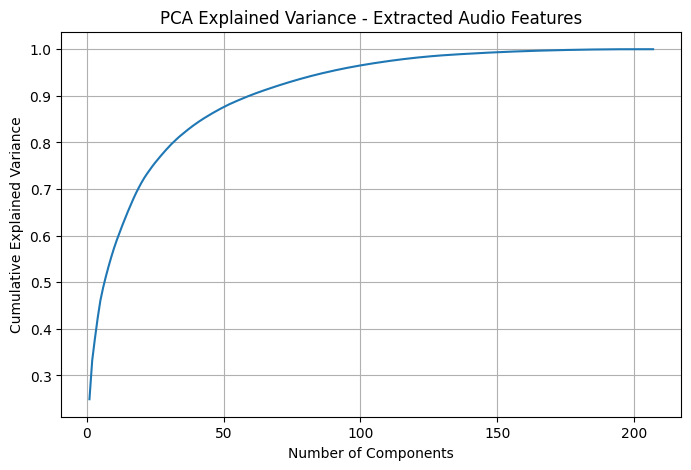

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained)+1),
    explained
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance - Extracted Audio Features")

plt.grid(True)

plt.show()

## PCA Component Optimization

Rather than selecting the number of principal components based solely on explained variance, several PCA configurations are evaluated.

The objective is to determine whether compressed extracted audio features improve recommendation quality compared to the original high-dimensional representation.

In [40]:
def build_audio_pca_features(
    audio_scaled,
    n_components
):
    pca = PCA(
        n_components=n_components,
        random_state=42
    )

    transformed = pca.fit_transform(audio_scaled)

    cols = [
        f"PCA_Audio_{i+1}"
        for i in range(n_components)
    ]

    df = pd.DataFrame(
        transformed,
        columns=cols,
        index=optimization_df.index
    )

    return df, pca

In [41]:
pca_feature_sets = {}

for n in [10, 20, 40, 60, 100]:

    df_pca, pca = build_audio_pca_features(
        audio_scaled,
        n
    )

    explained = pca.explained_variance_ratio_.sum()

    pca_feature_sets[n] = {
        "features": df_pca,
        "variance": explained
    }

    print(
        f"{n:>3} PCs -> "
        f"{explained:.3f} explained variance"
    )

 10 PCs -> 0.574 explained variance
 20 PCs -> 0.714 explained variance
 40 PCs -> 0.841 explained variance
 60 PCs -> 0.902 explained variance
100 PCs -> 0.965 explained variance


## Evaluating PCA-Based Audio Representations

The extracted audio features performed worse than expected when used in their full high-dimensional form.

To test whether this is caused by noise or dimensionality, we now evaluate compressed PCA versions of the extracted audio features.

Each PCA representation is combined with the Spotify feature group and evaluated with the same recommender metrics as before.

In [42]:
pca_columns_by_n = {}

for n, content in pca_feature_sets.items():
    pca_df = content["features"]

    for col in pca_df.columns:
        optimization_df[col] = pca_df[col]

    pca_columns_by_n[n] = pca_df.columns.tolist()

print("PCA columns added.")
print({n: len(cols) for n, cols in pca_columns_by_n.items()})

PCA columns added.
{10: 10, 20: 20, 40: 40, 60: 60, 100: 100}


In [43]:
pca_variants = {}

for n, pca_cols in pca_columns_by_n.items():
    pca_variants[f"Spotify + PCA Audio {n}"] = spotify_features + pca_cols

for name, cols in pca_variants.items():
    print(f"{name}: {len(cols)} features")

Spotify + PCA Audio 10: 20 features
Spotify + PCA Audio 20: 30 features
Spotify + PCA Audio 40: 50 features
Spotify + PCA Audio 60: 70 features
Spotify + PCA Audio 100: 110 features


In [44]:
pca_results = []

for name, cols in pca_variants.items():
    print(f"Evaluating: {name}")

    result = evaluate_feature_set(
        df=optimization_df,
        feature_columns=cols,
        model_name=name,
        sample_size=5000
    )

    pca_results.append(result)

pca_comparison_results = pd.concat(
    pca_results,
    ignore_index=True
)

pca_comparison_results

Evaluating: Spotify + PCA Audio 10
Evaluating: Spotify + PCA Audio 20
Evaluating: Spotify + PCA Audio 40
Evaluating: Spotify + PCA Audio 60
Evaluating: Spotify + PCA Audio 100


,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds
0,Spotify + PCA Audio 10,20,5,0.395111,0.98848,0.99584,9.36540,14.61
1,Spotify + PCA Audio 10,20,10,0.386722,0.98470,0.99470,9.92690,29.80
2,Spotify + PCA Audio 20,30,5,0.386658,0.98680,0.99556,11.22452,10.92
3,Spotify + PCA Audio 20,30,10,0.378723,0.98312,0.99430,11.73222,21.43
4,Spotify + PCA Audio 40,50,5,0.381585,0.98628,0.99592,12.93032,10.67
5,Spotify + PCA Audio 40,50,10,0.373932,0.98272,0.99430,13.34348,21.19
6,Spotify + PCA Audio 60,70,5,0.373795,0.98680,0.99560,14.03620,10.76
7,Spotify + PCA Audio 60,70,10,0.366364,0.98350,0.99464,14.23616,22.92
8,Spotify + PCA Audio 100,110,5,0.369050,0.98636,0.99544,14.83576,10.83
9,Spotify + PCA Audio 100,110,10,0.361096,0.98372,0.99436,14.98528,22.20


In [45]:
baseline_for_pca = feature_comparison_results[
    feature_comparison_results["Model"].isin([
        "Spotify Only",
        "Spotify + Extracted Audio",
        "Spotify + Lyrics",
        "All Features"
    ])
]

pca_full_comparison = pd.concat(
    [
        baseline_for_pca,
        pca_comparison_results
    ],
    ignore_index=True
)

pca_full_comparison[
    pca_full_comparison["k"] == 10
].sort_values(
    "Genre Overlap",
    ascending=False
)

,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds
3,Spotify + Lyrics,16,10,0.394553,0.98166,0.99376,8.25666,20.62
9,Spotify + PCA Audio 10,20,10,0.386722,0.98470,0.99470,9.92690,29.80
1,Spotify Only,10,10,0.386171,0.98658,0.99540,6.83548,26.86
11,Spotify + PCA Audio 20,30,10,0.378723,0.98312,0.99430,11.73222,21.43
13,Spotify + PCA Audio 40,50,10,0.373932,0.98272,0.99430,13.34348,21.19
15,Spotify + PCA Audio 60,70,10,0.366364,0.98350,0.99464,14.23616,22.92
17,Spotify + PCA Audio 100,110,10,0.361096,0.98372,0.99436,14.98528,22.20
7,All Features,223,10,0.361006,0.98434,0.99478,15.58386,19.61
5,Spotify + Extracted Audio,217,10,0.357612,0.98442,0.99480,15.56358,19.75


## Findings from Feature Group Optimization

The initial feature group comparison revealed several important observations.

### Feature Group Comparison

The recommender performed best when using **Spotify audio features together with lyrics features**. This combination achieved the highest genre overlap while using only 16 features.

Surprisingly, adding all 207 extracted low-level audio features reduced recommendation quality instead of improving it. This suggests that simply increasing the number of features does not necessarily produce better recommendations.

### PCA Optimization

To investigate whether the extracted audio features contained useful information hidden by their high dimensionality, Principal Component Analysis (PCA) was applied.

Several PCA representations were evaluated using different numbers of principal components.

The results showed that:

- PCA successfully improved the extracted audio representation compared to using all 207 extracted audio features.
- The best PCA configuration was obtained using **10 principal components**.
- Increasing the number of principal components beyond 10 gradually reduced recommendation quality, indicating that additional components mainly reintroduced noise instead of useful information.

### Current Best Models

| Model | Genre Overlap@10 |
|---------------------------|------:|
| Spotify + Lyrics | **0.3946** |
| Spotify + PCA Audio (10 PCs) | 0.3867 |
| Spotify Only | 0.3862 |
| Spotify + Extracted Audio | 0.3576 |
| All Features | 0.3610 |

These results indicate that **feature quality is considerably more important than feature quantity**. A carefully selected combination of informative features clearly outperforms simply combining every available feature group.

The next step is therefore to investigate whether assigning different importance (weights) to the strongest feature groups can further improve recommendation quality.

## Weight Optimization: Spotify and Lyrics

The previous experiments identified Spotify audio features and lyrics features as the two strongest feature groups.

Instead of treating both groups equally, this section investigates whether assigning different weights to each feature group further improves recommendation quality.

Each feature group is standardized independently before applying the selected weights. This ensures that the comparison reflects the contribution of each feature group rather than differences in scale or dimensionality.

In [46]:
def build_weighted_matrix(
    df,
    spotify_weight,
    lyrics_weight
):
    spotify = StandardScaler().fit_transform(
        df[spotify_features]
    )

    lyrics = StandardScaler().fit_transform(
        df[lyrics_features_final]
    )

    spotify *= spotify_weight
    lyrics *= lyrics_weight

    return np.hstack([
        spotify,
        lyrics
    ])

In [48]:
def evaluate_feature_matrix(
    metadata_df,
    X,
    model_name,
    k_values=[5, 10],
    sample_size=5000,
    random_state=42
):
    start_time = time.time()

    sample_idx = metadata_df.sample(
        n=min(sample_size, len(metadata_df)),
        random_state=random_state
    ).index

    eval_df = metadata_df.loc[sample_idx].reset_index(drop=True)

    if isinstance(X, pd.DataFrame):
        X_sample = X.loc[sample_idx].reset_index(drop=True)
    else:
        X_sample = X[sample_idx]

    max_k = max(k_values)

    model = NearestNeighbors(
        metric="cosine",
        algorithm="brute",
        n_neighbors=max_k + 1
    )

    model.fit(X_sample)

    distances, indices = model.kneighbors(X_sample)

    rows = []

    for k in k_values:
        genre_scores = []
        artist_diversity_scores = []
        album_diversity_scores = []
        popularity_diffs = []

        for i, neighbors in enumerate(indices):
            neighbor_idxs = [j for j in neighbors if j != i][:k]

            query_genres = eval_df.loc[i, "eval_genres"]
            neighbor_genres = eval_df.iloc[neighbor_idxs]["eval_genres"].tolist()

            genre_overlap = [
                jaccard(query_genres, genres)
                for genres in neighbor_genres
            ]

            genre_scores.append(np.mean(genre_overlap))

            neighbor_artists = eval_df.iloc[neighbor_idxs]["main_artist_id"].tolist()
            neighbor_albums = eval_df.iloc[neighbor_idxs]["album_id"].tolist()

            artist_diversity_scores.append(len(set(neighbor_artists)) / k)
            album_diversity_scores.append(len(set(neighbor_albums)) / k)

            query_popularity = eval_df.loc[i, "popularity"]
            neighbor_popularity = eval_df.iloc[neighbor_idxs]["popularity"]

            popularity_diffs.append(
                np.mean(np.abs(neighbor_popularity - query_popularity))
            )

        rows.append({
            "Model": model_name,
            "Features": X_sample.shape[1],
            "k": k,
            "Genre Overlap": np.mean(genre_scores),
            "Artist Diversity": np.mean(artist_diversity_scores),
            "Album Diversity": np.mean(album_diversity_scores),
            "Avg Popularity Difference": np.mean(popularity_diffs),
            "Runtime Seconds": round(time.time() - start_time, 2)
        })

    del eval_df, X_sample, model, distances, indices
    gc.collect()

    return pd.DataFrame(rows)

In [49]:
X_spotify_lyrics_equal = build_weighted_matrix(
    optimization_df,
    spotify_weight=1.0,
    lyrics_weight=1.0
)

weighted_test = evaluate_feature_matrix(
    metadata_df=optimization_df,
    X=X_spotify_lyrics_equal,
    model_name="Spotify + Lyrics Equal Weight",
    sample_size=5000
)

weighted_test

,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds
0,Spotify + Lyrics Equal Weight,16,5,0.403944,0.98744,0.99544,7.53452,11.40
1,Spotify + Lyrics Equal Weight,16,10,0.393887,0.98136,0.99384,8.09486,21.73


## Weight Search for Spotify and Lyrics

The equal-weight model performs well, but Spotify audio features and lyrics features may not contribute equally.

A small grid search is used to test different Spotify/Lyrics weight combinations. The goal is to find whether a different balance improves genre overlap while keeping recommendation diversity stable.

In [51]:
weight_configs = [
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
]

weighted_results = []

for spotify_w, lyrics_w in weight_configs:
    model_name = f"Spotify {spotify_w:.1f} / Lyrics {lyrics_w:.1f}"
    print(f"Evaluating: {model_name}")

    X_weighted = build_weighted_matrix(
        optimization_df,
        spotify_weight=spotify_w,
        lyrics_weight=lyrics_w
    )

    result = evaluate_feature_matrix(
        metadata_df=optimization_df,
        X=X_weighted,
        model_name=model_name,
        sample_size=5000
    )

    result["Spotify Weight"] = spotify_w
    result["Lyrics Weight"] = lyrics_w

    weighted_results.append(result)

weighted_results_df = pd.concat(
    weighted_results,
    ignore_index=True
)

weighted_results_df

Evaluating: Spotify 0.9 / Lyrics 0.1
Evaluating: Spotify 0.8 / Lyrics 0.2
Evaluating: Spotify 0.7 / Lyrics 0.3
Evaluating: Spotify 0.6 / Lyrics 0.4
Evaluating: Spotify 0.5 / Lyrics 0.5
Evaluating: Spotify 0.4 / Lyrics 0.6
Evaluating: Spotify 0.3 / Lyrics 0.7
Evaluating: Spotify 0.2 / Lyrics 0.8
Evaluating: Spotify 0.1 / Lyrics 0.9


,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds,Spotify Weight,Lyrics Weight
0,Spotify 0.9 / Lyrics 0.1,16,5,0.394668,0.99184,0.99672,6.23256,15.28,0.9,0.1
1,Spotify 0.9 / Lyrics 0.1,16,10,0.388228,0.98620,0.99524,6.81928,28.36,0.9,0.1
2,Spotify 0.8 / Lyrics 0.2,16,5,0.398936,0.99088,0.99632,6.37648,11.02,0.8,0.2
3,Spotify 0.8 / Lyrics 0.2,16,10,0.392019,0.98562,0.99494,6.96344,21.58,0.8,0.2
4,Spotify 0.7 / Lyrics 0.3,16,5,0.403711,0.98936,0.99588,6.68324,10.72,0.7,0.3
5,Spotify 0.7 / Lyrics 0.3,16,10,0.393781,0.98434,0.99458,7.22696,22.27,0.7,0.3
6,Spotify 0.6 / Lyrics 0.4,16,5,0.404988,0.98768,0.99544,7.01252,12.41,0.6,0.4
7,Spotify 0.6 / Lyrics 0.4,16,10,0.395048,0.98212,0.99410,7.61312,26.26,0.6,0.4
8,Spotify 0.5 / Lyrics 0.5,16,5,0.403944,0.98744,0.99544,7.53452,12.87,0.5,0.5
9,Spotify 0.5 / Lyrics 0.5,16,10,0.393887,0.98136,0.99384,8.09486,27.10,0.5,0.5


In [52]:
weighted_results_df[
    weighted_results_df["k"] == 10
].sort_values(
    "Genre Overlap",
    ascending=False
)

,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds,Spotify Weight,Lyrics Weight
7,Spotify 0.6 / Lyrics 0.4,16,10,0.395048,0.98212,0.99410,7.61312,26.26,0.6,0.4
9,Spotify 0.5 / Lyrics 0.5,16,10,0.393887,0.98136,0.99384,8.09486,27.10,0.5,0.5
5,Spotify 0.7 / Lyrics 0.3,16,10,0.393781,0.98434,0.99458,7.22696,22.27,0.7,0.3
11,Spotify 0.4 / Lyrics 0.6,16,10,0.392714,0.98090,0.99360,8.79316,22.92,0.4,0.6
3,Spotify 0.8 / Lyrics 0.2,16,10,0.392019,0.98562,0.99494,6.96344,21.58,0.8,0.2
13,Spotify 0.3 / Lyrics 0.7,16,10,0.388868,0.98028,0.99330,9.65632,25.58,0.3,0.7
1,Spotify 0.9 / Lyrics 0.1,16,10,0.388228,0.98620,0.99524,6.81928,28.36,0.9,0.1
15,Spotify 0.2 / Lyrics 0.8,16,10,0.380248,0.98056,0.99340,10.95962,28.84,0.2,0.8
17,Spotify 0.1 / Lyrics 0.9,16,10,0.360622,0.97996,0.99332,13.50354,27.17,0.1,0.9


## Adding PCA Audio to the Weighted Model

The best Spotify/Lyrics weighting so far is 0.6 / 0.4.

Since PCA Audio with 10 components performed better than the full extracted audio feature set, we now test whether adding a small PCA audio contribution improves the weighted recommender.

The PCA audio component is kept smaller than Spotify and lyrics because previous experiments showed that extracted audio features were less useful overall.

In [53]:
def build_weighted_matrix_with_pca_audio(
    df,
    spotify_weight,
    lyrics_weight,
    pca_audio_weight,
    pca_audio_cols
):
    spotify = StandardScaler().fit_transform(
        df[spotify_features]
    )

    lyrics = StandardScaler().fit_transform(
        df[lyrics_features_final]
    )

    pca_audio = StandardScaler().fit_transform(
        df[pca_audio_cols]
    )

    spotify *= spotify_weight
    lyrics *= lyrics_weight
    pca_audio *= pca_audio_weight

    return np.hstack([
        spotify,
        lyrics,
        pca_audio
    ])

In [54]:
pca10_cols = pca_columns_by_n[10]

hybrid_weight_configs = [
    (0.6, 0.4, 0.0),
    (0.6, 0.3, 0.1),
    (0.5, 0.4, 0.1),
    (0.5, 0.3, 0.2),
    (0.7, 0.2, 0.1),
    (0.4, 0.4, 0.2),
]

hybrid_results = []

for spotify_w, lyrics_w, pca_w in hybrid_weight_configs:
    model_name = f"Spotify {spotify_w:.1f} / Lyrics {lyrics_w:.1f} / PCA10 {pca_w:.1f}"
    print(f"Evaluating: {model_name}")

    X_hybrid = build_weighted_matrix_with_pca_audio(
        df=optimization_df,
        spotify_weight=spotify_w,
        lyrics_weight=lyrics_w,
        pca_audio_weight=pca_w,
        pca_audio_cols=pca10_cols
    )

    result = evaluate_feature_matrix(
        metadata_df=optimization_df,
        X=X_hybrid,
        model_name=model_name,
        sample_size=5000
    )

    result["Spotify Weight"] = spotify_w
    result["Lyrics Weight"] = lyrics_w
    result["PCA Audio Weight"] = pca_w

    hybrid_results.append(result)

hybrid_results_df = pd.concat(
    hybrid_results,
    ignore_index=True
)

hybrid_results_df

Evaluating: Spotify 0.6 / Lyrics 0.4 / PCA10 0.0
Evaluating: Spotify 0.6 / Lyrics 0.3 / PCA10 0.1
Evaluating: Spotify 0.5 / Lyrics 0.4 / PCA10 0.1
Evaluating: Spotify 0.5 / Lyrics 0.3 / PCA10 0.2
Evaluating: Spotify 0.7 / Lyrics 0.2 / PCA10 0.1
Evaluating: Spotify 0.4 / Lyrics 0.4 / PCA10 0.2


,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds,Spotify Weight,Lyrics Weight,PCA Audio Weight
0,Spotify 0.6 / Lyrics 0.4 / PCA10 0.0,26,5,0.404988,0.98768,0.99544,7.01252,19.75,0.6,0.4,0.0
1,Spotify 0.6 / Lyrics 0.4 / PCA10 0.0,26,10,0.395048,0.98212,0.99410,7.61312,32.53,0.6,0.4,0.0
2,Spotify 0.6 / Lyrics 0.3 / PCA10 0.1,26,5,0.406378,0.98880,0.99544,6.92080,11.05,0.6,0.3,0.1
3,Spotify 0.6 / Lyrics 0.3 / PCA10 0.1,26,10,0.396422,0.98316,0.99418,7.46972,21.89,0.6,0.3,0.1
4,Spotify 0.5 / Lyrics 0.4 / PCA10 0.1,26,5,0.406329,0.98764,0.99504,7.37892,11.05,0.5,0.4,0.1
5,Spotify 0.5 / Lyrics 0.4 / PCA10 0.1,26,10,0.397673,0.98150,0.99400,7.97072,21.64,0.5,0.4,0.1
6,Spotify 0.5 / Lyrics 0.3 / PCA10 0.2,26,5,0.409920,0.98716,0.99528,7.66392,12.12,0.5,0.3,0.2
7,Spotify 0.5 / Lyrics 0.3 / PCA10 0.2,26,10,0.401362,0.98180,0.99360,8.14122,22.45,0.5,0.3,0.2
8,Spotify 0.7 / Lyrics 0.2 / PCA10 0.1,26,5,0.403634,0.99032,0.99612,6.54580,10.98,0.7,0.2,0.1
9,Spotify 0.7 / Lyrics 0.2 / PCA10 0.1,26,10,0.395275,0.98492,0.99456,7.10570,21.86,0.7,0.2,0.1


In [55]:
hybrid_results_df[
    hybrid_results_df["k"] == 10
].sort_values(
    "Genre Overlap",
    ascending=False
)

,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds,Spotify Weight,Lyrics Weight,PCA Audio Weight
11,Spotify 0.4 / Lyrics 0.4 / PCA10 0.2,26,10,0.402145,0.98002,0.99348,8.91134,21.36,0.4,0.4,0.2
7,Spotify 0.5 / Lyrics 0.3 / PCA10 0.2,26,10,0.401362,0.98180,0.99360,8.14122,22.45,0.5,0.3,0.2
5,Spotify 0.5 / Lyrics 0.4 / PCA10 0.1,26,10,0.397673,0.98150,0.99400,7.97072,21.64,0.5,0.4,0.1
3,Spotify 0.6 / Lyrics 0.3 / PCA10 0.1,26,10,0.396422,0.98316,0.99418,7.46972,21.89,0.6,0.3,0.1
9,Spotify 0.7 / Lyrics 0.2 / PCA10 0.1,26,10,0.395275,0.98492,0.99456,7.10570,21.86,0.7,0.2,0.1
1,Spotify 0.6 / Lyrics 0.4 / PCA10 0.0,26,10,0.395048,0.98212,0.99410,7.61312,32.53,0.6,0.4,0.0


## Fine-Tuning the Best Hybrid Weights

The first hybrid search showed that adding a small PCA audio contribution improves recommendation quality.

The best initial configuration was:

- Spotify: 0.4
- Lyrics: 0.4
- PCA Audio: 0.2

A smaller fine search is now performed around this configuration to check whether a nearby weight combination performs even better.

In [56]:
fine_hybrid_weight_configs = [
    (0.45, 0.35, 0.20),
    (0.40, 0.40, 0.20),
    (0.35, 0.45, 0.20),
    (0.45, 0.40, 0.15),
    (0.40, 0.45, 0.15),
    (0.35, 0.40, 0.25),
    (0.40, 0.35, 0.25),
]

fine_hybrid_results = []

for spotify_w, lyrics_w, pca_w in fine_hybrid_weight_configs:
    model_name = f"Spotify {spotify_w:.2f} / Lyrics {lyrics_w:.2f} / PCA10 {pca_w:.2f}"
    print(f"Evaluating: {model_name}")

    X_hybrid = build_weighted_matrix_with_pca_audio(
        df=optimization_df,
        spotify_weight=spotify_w,
        lyrics_weight=lyrics_w,
        pca_audio_weight=pca_w,
        pca_audio_cols=pca10_cols
    )

    result = evaluate_feature_matrix(
        metadata_df=optimization_df,
        X=X_hybrid,
        model_name=model_name,
        sample_size=5000
    )

    result["Spotify Weight"] = spotify_w
    result["Lyrics Weight"] = lyrics_w
    result["PCA Audio Weight"] = pca_w

    fine_hybrid_results.append(result)

fine_hybrid_results_df = pd.concat(
    fine_hybrid_results,
    ignore_index=True
)

fine_hybrid_results_df[
    fine_hybrid_results_df["k"] == 10
].sort_values(
    "Genre Overlap",
    ascending=False
)

Evaluating: Spotify 0.45 / Lyrics 0.35 / PCA10 0.20
Evaluating: Spotify 0.40 / Lyrics 0.40 / PCA10 0.20
Evaluating: Spotify 0.35 / Lyrics 0.45 / PCA10 0.20
Evaluating: Spotify 0.45 / Lyrics 0.40 / PCA10 0.15
Evaluating: Spotify 0.40 / Lyrics 0.45 / PCA10 0.15
Evaluating: Spotify 0.35 / Lyrics 0.40 / PCA10 0.25
Evaluating: Spotify 0.40 / Lyrics 0.35 / PCA10 0.25


,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds,Spotify Weight,Lyrics Weight,PCA Audio Weight
1,Spotify 0.45 / Lyrics 0.35 / PCA10 0.20,26,10,0.402178,0.98042,0.99352,8.47050,24.25,0.45,0.35,0.20
3,Spotify 0.40 / Lyrics 0.40 / PCA10 0.20,26,10,0.402145,0.98002,0.99348,8.91134,22.04,0.40,0.40,0.20
13,Spotify 0.40 / Lyrics 0.35 / PCA10 0.25,26,10,0.400970,0.98096,0.99360,9.16430,23.67,0.40,0.35,0.25
7,Spotify 0.45 / Lyrics 0.40 / PCA10 0.15,26,10,0.400593,0.98056,0.99388,8.31792,21.78,0.45,0.40,0.15
5,Spotify 0.35 / Lyrics 0.45 / PCA10 0.20,26,10,0.400381,0.97958,0.99368,9.47072,23.94,0.35,0.45,0.20
11,Spotify 0.35 / Lyrics 0.40 / PCA10 0.25,26,10,0.399544,0.98008,0.99354,9.75054,21.64,0.35,0.40,0.25
9,Spotify 0.40 / Lyrics 0.45 / PCA10 0.15,26,10,0.399369,0.98014,0.99388,8.72728,22.29,0.40,0.45,0.15


## Final Recommender Selection

The optimization process compared multiple feature groups, PCA-based representations, and weighted feature combinations.

The final hybrid recommender achieved the highest recommendation quality while maintaining a compact feature representation.

The selected configuration combines:

- Spotify audio features
- Lyrics features
- PCA-compressed extracted audio features (10 principal components)

using the optimized weights:

- Spotify: **0.45**
- Lyrics: **0.35**
- PCA Audio: **0.20**

This configuration will be used as the recommendation engine for the interactive dashboard developed in the next notebook.

In [57]:
final_models = pd.concat([
    feature_comparison_results,
    pca_full_comparison,
    weighted_results_df,
    fine_hybrid_results_df
], ignore_index=True)

final_models = (
    final_models[final_models["k"] == 10]
    .sort_values("Genre Overlap", ascending=False)
    .drop_duplicates("Model")
)

final_models.head(15)

,Model,Features,k,Genre Overlap,Artist Diversity,Album Diversity,Avg Popularity Difference,Runtime Seconds,Spotify Weight,Lyrics Weight,PCA Audio Weight
51,Spotify 0.45 / Lyrics 0.35 / PCA10 0.20,26,10,0.402178,0.98042,0.99352,8.47050,24.25,0.45,0.35,0.20
53,Spotify 0.40 / Lyrics 0.40 / PCA10 0.20,26,10,0.402145,0.98002,0.99348,8.91134,22.04,0.40,0.40,0.20
63,Spotify 0.40 / Lyrics 0.35 / PCA10 0.25,26,10,0.400970,0.98096,0.99360,9.16430,23.67,0.40,0.35,0.25
57,Spotify 0.45 / Lyrics 0.40 / PCA10 0.15,26,10,0.400593,0.98056,0.99388,8.31792,21.78,0.45,0.40,0.15
55,Spotify 0.35 / Lyrics 0.45 / PCA10 0.20,26,10,0.400381,0.97958,0.99368,9.47072,23.94,0.35,0.45,0.20
61,Spotify 0.35 / Lyrics 0.40 / PCA10 0.25,26,10,0.399544,0.98008,0.99354,9.75054,21.64,0.35,0.40,0.25
59,Spotify 0.40 / Lyrics 0.45 / PCA10 0.15,26,10,0.399369,0.98014,0.99388,8.72728,22.29,0.40,0.45,0.15
39,Spotify 0.6 / Lyrics 0.4,16,10,0.395048,0.98212,0.99410,7.61312,26.26,0.60,0.40,NaN
7,Spotify + Lyrics,16,10,0.394553,0.98166,0.99376,8.25666,20.62,NaN,NaN,NaN
41,Spotify 0.5 / Lyrics 0.5,16,10,0.393887,0.98136,0.99384,8.09486,27.10,0.50,0.50,NaN


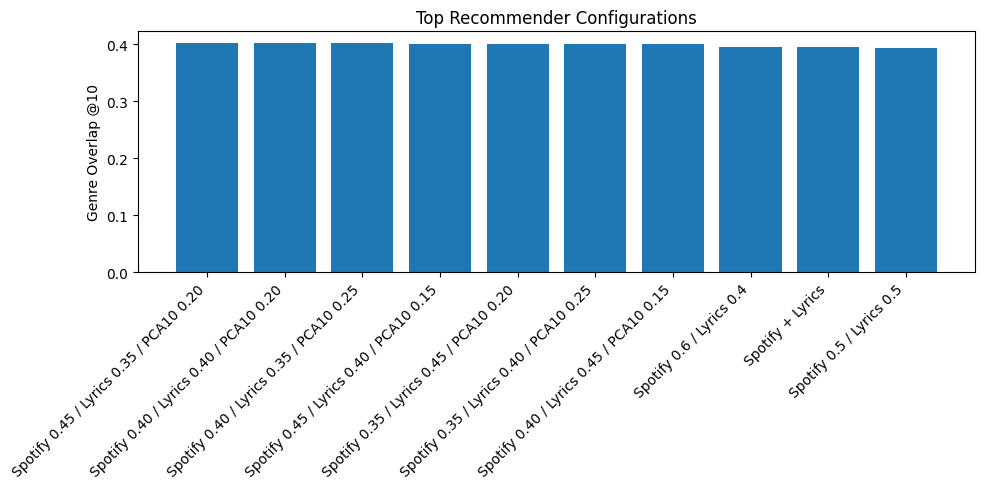

In [58]:
import matplotlib.pyplot as plt

top_models = final_models.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_models["Model"],
    top_models["Genre Overlap"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Genre Overlap @10")
plt.title("Top Recommender Configurations")

plt.tight_layout()
plt.show()

### Saving the Model

In [59]:
import json
import joblib

optimized_config = {
    "model_name": "weighted_hybrid_recommender",
    "spotify_weight": 0.40,
    "lyrics_weight": 0.40,
    "pca_audio_weight": 0.20,
    "pca_components": 10,
    "spotify_features": spotify_features,
    "lyrics_features": lyrics_features_final,
    "extracted_audio_features": extracted_audio_features
}

models_dir.mkdir(parents=True, exist_ok=True)

with open(models_dir / "optimized_recommender_config.json", "w") as f:
    json.dump(optimized_config, f, indent=4)

joblib.dump(pca_feature_sets[10]["features"], models_dir / "pca10_audio_features.joblib")

print("Saved optimized recommender configuration.")

Saved optimized recommender configuration.
